In [3]:
import pandas as pd
import numpy as np 
import keras
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error 
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import joblib # Para salvar os normalizadores
from tensorflow.keras import initializers
import os

In [5]:
def create_delta_data(local_data):
    OriginalData = pd.read_csv(local_data)
    OriginalData.index = (np.arange(0, len(OriginalData), 1).astype(float) * 0.07).round(5)
    OriginalData = OriginalData.drop(columns=["x(Wd,We)", "y(Wd,We)", "tempo"])
    theta = OriginalData["theta(Wd,We)"].to_numpy()
    theta_0 = theta[:-1]
    theta_1 = theta[1:]
    delta_theta = (theta_1 - theta_0) / 0.07
    wd_alinhado = OriginalData['Wd'].iloc[:-1]  
    we_alinhado = OriginalData['We'].iloc[:-1] 
    wd_true_alinhado = OriginalData['Wd_true'].iloc[:-1]
    we_true_alinhado = OriginalData['We_true'].iloc[:-1]
    df_new = pd.DataFrame({
        'Wd': wd_alinhado,
        'We': we_alinhado,
        'delta_theta': delta_theta,
        'Wd_true': wd_true_alinhado,
        'We_true': we_true_alinhado
    })
    print(df_new.head())
    print("Shape do novo_df:", df_new.shape)
    return df_new

In [6]:
def root_mean_squared_error(y_true, y_pred):
    y_true_np = y_true.numpy() if hasattr(y_true, 'numpy') else y_true
    y_pred_np = y_pred.numpy() if hasattr(y_pred, 'numpy') else y_pred
    return np.sqrt(mean_squared_error(y_true_np, y_pred_np))

def custom_train_model_with_es_physics(model,
                                       train_x, train_y,
                                       x_val, y_val,
                                       x_test, y_test,
                                       restrictions_data,
                                       Ts, L, R,
                                       y_scaler,
                                       lambda1=1.0, lambda2=1.0,
                                       epochs=5000, patience=50,
                                       min_delta=0, plot=True,
                                       learning_rate=0.001, use_early_stopping=True):
    """
    Treina um modelo Keras com Adam + Early Stopping e adiciona um termo
    físico MSE_f na loss:

        MSE_f = mean( ((y[k] - y[k-1]) / Ts - (R/L)*(Wd[k-1] - We[k-1]))^2 )

    Loss = lambda1 * MSE_d + lambda2 * MSE_f
    """

    # converter para tf.Tensor float32
    def to_tensor(x):
        return tf.constant(x, dtype=tf.float32) if not tf.is_tensor(x) else tf.cast(x, tf.float32)
    train_x = to_tensor(train_x); train_y = to_tensor(train_y)
    x_val   = to_tensor(x_val);   y_val   = to_tensor(y_val)
    x_test  = to_tensor(x_test);  y_test  = to_tensor(y_test)
    #restrictions_data = to_tensor(restrictions_data)

    optimizer = Adam(learning_rate=learning_rate)
    mse_loss  = MeanSquaredError()

    train_hist, val_hist = [], []
    best_val, wait, best_w = float('inf'), 0, None

    print(f"Treinando com Ts={Ts}, L={L}, R={R}, λ1={lambda1}, λ2={lambda2}")
    for epoch in range(1, epochs+1):
        with tf.GradientTape() as tape:
            # 1) predições
            y_pred = model(train_x, training=True)  # shape [N,1]

            # 2) termo convencional MSE_d
            MSE_d = mse_loss(train_y, y_pred)

            # 3) termo físico MSE_f
            # descartamos o primeiro ponto: predições[1:], predições[:-1]
            #y_k   = y_pred[1:]
            #y_km1 = y_pred[:-1]
            # entradas correspondentes Wd, We no instante k-1
            x1_km1 = restrictions_data[:, 0]   # Wd
            x2_km1 = restrictions_data[:, 1]   # We
            #x1_km1 = train_x[:, 0]  # Wd
            #x2_km1 = train_x[:, 1]  # We
            # calcula derivada aproximada
            #dy_dt = (y_k - y_km1) / Ts
            phys_real  = ((R / L) * (x1_km1 - x2_km1)) 

            phys_real = phys_real.reshape((-1, 1))  # shape [N-1, 1]
            phys_norm = y_scaler.transform(phys_real)
            MSE_f = tf.reduce_mean(tf.square(y_pred - phys_norm))

            # 4) loss total
            loss = lambda1 * MSE_d + lambda2 * MSE_f

        # grads e atualização
        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))

        # validação
        yv = model(x_val, training=False)
        val_d = mse_loss(y_val, yv)
        # para simplicidade não calculo val_f

        train_hist.append(loss.numpy())
        val_hist.append(val_d.numpy())

        if use_early_stopping:
        # early stopping
            if val_d.numpy() < best_val - min_delta:
                best_val = val_d.numpy(); wait = 0
                best_w = model.get_weights()
            else:
                wait += 1

            if wait >= patience:
                print(f"Early stopping na época {epoch}")
                model.set_weights(best_w)
                break

        if epoch % (epochs/5) == 0 or epoch == 1:
            print(f"Epoch {epoch}: Loss={loss.numpy():.4g}, MSE_d={MSE_d.numpy():.4g}, MSE_f={MSE_f.numpy():.4g}, Val MSE={val_d.numpy():.4g}")

    # avaliando métricas finais
    def eval_metrics(x, y):
        yp = model(x, training=False)
        y_np, yp_np = y.numpy(), yp.numpy()
        return {
            'R2': r2_score(y_np, yp_np),
            'MSE': mean_squared_error(y_np, yp_np),
            'RMSE': root_mean_squared_error(y_np, yp_np),
            'MAPE': mean_absolute_percentage_error(y_np, yp_np)
        }

    metrics = {
        'Training':   eval_metrics(train_x, train_y),
        'Validation': eval_metrics(x_val,   y_val),
        'Test':       eval_metrics(x_test,  y_test),
    }
    if plot:
        for split, m in metrics.items():
            print(f"\n{split} Metrics:")
            for k, v in m.items():
                print(f"  {k}: {v:.4g}")
            
    train_pred = model.predict(train_x)
    val_pred = model.predict(x_val)
    test_pred = model.predict(x_test)

    # CORREÇÃO: Conversão robusta para arrays numpy para cálculo de métricas sklearn
    # Usamos hasattr(var, 'numpy') para verificar se é um Tensor antes de chamar .numpy()
    train_y_np = train_y.numpy() if hasattr(train_y, 'numpy') else train_y
    train_pred_np = train_pred.numpy() if hasattr(train_pred, 'numpy') else train_pred
    y_val_np = y_val.numpy() if hasattr(y_val, 'numpy') else y_val
    val_pred_np = val_pred.numpy() if hasattr(val_pred, 'numpy') else val_pred
    y_test_np = y_test.numpy() if hasattr(y_test, 'numpy') else y_test
    test_pred_np = test_pred.numpy() if hasattr(test_pred, 'numpy') else test_pred
    # opcional: plot de loss
    if plot:
        plt.plot(train_hist, label='Train Loss')
        plt.plot(val_hist,   label='Val MSE_d')
        plt.xlabel('Epoch'); plt.ylabel('Loss')
        plt.legend(); plt.grid(True)
        plt.show()

        # Gráficos comparativos
        fig, axs = plt.subplots(3, 1, figsize=(12, 12))
        datasets = [
            ('Treinamento', train_y_np, train_pred_np), 
            ('Validação', y_val_np, val_pred_np),
            ('Teste', y_test_np, test_pred_np)
        ]

        for i, (title, y_true, y_pred) in enumerate(datasets):
            y_true_flat = np.ravel(y_true)
            y_pred_flat = np.ravel(y_pred)
            axs[i].plot(y_true_flat, marker='o', label='Amostras Reais')
            axs[i].plot(y_pred_flat, marker='x', label='Valores Preditos')
            axs[i].set_title(f'{title}')
            axs[i].set_xlabel('Índice')
            axs[i].set_ylabel('Valor')
            axs[i].legend()
            axs[i].grid(True)

        plt.suptitle('Comparação: Amostras Reais vs Valores Preditos')
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

        #print(model.trainable_variables)

    return metrics

In [7]:
def create_sequences(input_data, target_data, timesteps):

    X_seq, Y_seq = [], []
    
    # Itera sobre os dados, começando após o número de timesteps
    for i in range(timesteps, len(input_data)):
        # A sequência de entrada (X_seq) é a janela de dados de i-timesteps até i
        X_seq.append(input_data[i-timesteps:i])
        
        # O alvo (Y_seq) é o valor de saída no passo de tempo atual 'i'
        Y_seq.append(target_data[i])
    
    return np.array(X_seq), np.array(Y_seq)

In [8]:
def Recontruir_Theta(model, inputs_norm, local_data_original, y_scaler):
    """
    Reconstrói o sinal de Theta a partir da previsão de sua derivada,
    e calcula o MSE de forma correta e alinhada.
    """

    Y_norm_pred = model.predict(inputs_norm)
    Y_pred_real = y_scaler.inverse_transform(Y_norm_pred) # Derivada na escala real

    DataOrigi = pd.read_csv(local_data_original)
    Theta_true = DataOrigi["theta(Wd,We)"].to_numpy()
    theta_reconstruido = np.zeros_like(Y_pred_real)
    theta_reconstruido[0] = Theta_true[0] + Y_pred_real[0] * 0.07


    for i in range(1, len(Y_pred_real)):
        # Fórmula da integração de Euler: y(t) = y(t-1) + y'(t) * dt
        theta_reconstruido[i] = theta_reconstruido[i-1] + Y_pred_real[i] * 0.07
    

    offset = len(Theta_true) - len(theta_reconstruido)
    Theta_true_alinhado = Theta_true[offset:]

    # O cálculo do MSE agora é feito entre dois vetores do mesmo tamanho.
    mse = np.mean(np.square(Theta_true_alinhado - theta_reconstruido))
    
    print(f"MSE entre Theta Original e Reconstruído: {mse:.4g}")

    # Plotando os dados alinhados
    plt.figure(figsize=(14, 6))
    plt.plot(Theta_true_alinhado, label='Theta Original (Alinhado)', color='orange', linestyle='--')
    plt.plot(theta_reconstruido, label='Theta Reconstruído', color='blue', alpha=0.8)
    plt.xlabel('Índice da Amostra (Alinhado)')
    plt.ylabel('Theta (rad)')
    plt.title('Comparação de Theta Reconstruído vs Original')
    plt.legend()
    plt.grid(True)
    plt.show() # Adicionado para exibir o gráfico
    
    return mse

def Aval_Thetha(model, time_steps, y_scaler):
    train_x_seq, train_y_seq = create_sequences(train_x_norm, train_y_norm, time_steps)
    x_val_seq, y_val_seq = create_sequences(x_val_norm, y_val_norm, time_steps)
    x_test_seq, y_test_seq = create_sequences(x_test_norm, y_test_norm, time_steps)
    mse_train = Recontruir_Theta(model, train_x_seq, "./Dados/Data2SmoothSpline1.csv", y_scaler)
    mse_val = Recontruir_Theta(model, x_val_seq, "./Dados/Data2SmoothSpline2.csv", y_scaler)
    mse_test = Recontruir_Theta(model, x_test_seq, "./Dados/Data2SmoothSpline3.csv", y_scaler)
    return [mse_train, mse_val, mse_test]

In [9]:
def CreateModel(input_size = 2, output_size = 1, units = 10, time_steps = 2, 
                n_seed = [32, 67, 90, 546, 801], lam_1 = 1.0, lam_2 = 0.0, lr = 0.01, l2 = 0.8):
    """
    Cria um modelo Sequential com uma camada RNN e uma camada Dense.

    """
    train_x_seq, train_y_seq = create_sequences(train_x_norm, train_y_norm, time_steps)
    x_val_seq, y_val_seq = create_sequences(x_val_norm, y_val_norm, time_steps)
    x_test_seq, y_test_seq = create_sequences(x_test_norm, y_test_norm, time_steps)
    
    model = keras.models.Sequential([
        keras.layers.SimpleRNN(units, return_sequences=False, input_shape=[time_steps, input_size],
                               kernel_initializer=initializers.GlorotUniform(seed=int(n_seed[0])),
                               recurrent_initializer=initializers.Orthogonal(seed=int(n_seed[1])),
                               bias_initializer=initializers.RandomNormal(seed=int(n_seed[2])),
                               kernel_regularizer= keras.regularizers.l2(l2)),
        #keras.layers.Dense(output_size, activation='linear',use_bias=False,kernel_initializer=initializers.GlorotUniform(seed=int(n_seed[3])))
        keras.layers.Dense(output_size,
        kernel_initializer=initializers.GlorotUniform(seed=int(n_seed[3])),
        bias_initializer=initializers.RandomNormal(seed=int(n_seed[4])))
    ])

    metrics = custom_train_model_with_es_physics(model,
                                       train_x = train_x_seq, train_y = train_y_seq,
                                       x_val = x_val_seq, y_val = y_val_seq,
                                       x_test = x_test_seq, y_test = y_test_seq,
                                       restrictions_data = Restrictions_data[:-time_steps,:],
                                       Ts = 0.07, L = 0.123, R = 0.034,
                                       y_scaler= y_scaler,
                                       lambda1= lam_1, lambda2=lam_2,
                                       epochs = 10000, patience=500,
                                       min_delta=0, plot=False,
                                       learning_rate= lr, use_early_stopping=True)

    
    return model, metrics

In [10]:
def Generate_Random_Models(units=10, time_steps=2, lam_1=0.5, lam_2=0.5, lr = 0.001, aval= True, l2 = 0.8):
    """
    Treina vários modelos com seeds e learning rates aleatórios,
    retornando o melhor modelo encontrado com base no MSE de teste.
    """
    best_test_mse = float('inf')
    best_test_r2 = None
    best_model = None
    best_metrics = None

    for i in range(10):
        # Seed aleatória
        np_seed = np.random.randint(1, 10000, size = 5)


        print(f"Modelo {i+1}: unidades = {units}, seed = {np_seed}, lr = {lr:.5f}")

        # Criação e treino do modelo
        model, metrics = CreateModel(
            units=units,
            time_steps=time_steps,
            lam_1=lam_1,
            lam_2=lam_2,
            n_seed=np_seed,
            lr=lr,
            l2 = l2
        )

        # Métricas do teste
        test_mse = metrics['Test']['MSE']
        if test_mse < best_test_mse:
            best_test_mse = test_mse
            best_model = model
            best_test_r2 = metrics['Test']['R2']
            best_metrics = metrics
            print(f"Novo melhor modelo: MSE = {best_test_mse:.4g}, R2 = {best_test_r2:.4g}, lr = {lr:.5f}")

    print(f"\nMelhor modelo final: MSE = {best_test_mse:.4g}, R2 = {best_test_r2:.4g}, unidades = {units},  lr = {lr:.5f}")
    if aval:
        Aval_Thetha(best_model, time_steps, y_scaler)

    return best_model, best_metrics


In [11]:
TrainData = create_delta_data("./Dados/Data2SmoothSpline1.csv")
TestData = create_delta_data("./Dados/Data2SmoothSpline3.csv")
ValData = create_delta_data("./Dados/Data2SmoothSpline2.csv")

# Define predictors and target
PREDICTORS = ["Wd", "We"]
TARGET = "delta_theta"
RESTRICTIONS = ["Wd_true", "We_true"]


Restrictions_data = TrainData[RESTRICTIONS].to_numpy()

print("\nShape de Restrictions_data:", Restrictions_data.shape)
print("Primeiras linhas de Restrictions_data:\n", Restrictions_data[:5])

# Convertendo para arrays numpy
train_x = TrainData[PREDICTORS].to_numpy()
train_y = TrainData[[TARGET]].to_numpy()
print(train_x.shape)

x_val = ValData[PREDICTORS].to_numpy()
y_val = ValData[[TARGET]].to_numpy()

x_test = TestData[PREDICTORS].to_numpy()
y_test = TestData[[TARGET]].to_numpy()


x_scaler = MinMaxScaler(feature_range=(-1, 1))
y_scaler = MinMaxScaler(feature_range=(-1, 1))

print("\nAjustando os normalizadores (scalers) com os dados de treino...")
x_scaler.fit(train_x)
y_scaler.fit(train_y)

joblib.dump(x_scaler, 'x_scaler.gz')
joblib.dump(y_scaler, 'y_scaler.gz')
print("Normalizadores salvos como 'x_scaler.gz' e 'y_scaler.gz'")

# AGORA, TRANSFORME TODOS OS CONJUNTOS DE DADOS com os scalers já ajustados
train_x_norm = x_scaler.transform(train_x)
train_y_norm = y_scaler.transform(train_y)

x_val_norm = x_scaler.transform(x_val)
y_val_norm = y_scaler.transform(y_val)

x_test_norm = x_scaler.transform(x_test)
y_test_norm = y_scaler.transform(y_test)

restric_norm = x_scaler.transform(Restrictions_data)
print("\nShape de Restrictions_data normalizado:", restric_norm.shape)

print("\nShape de X_train depois da normalização:", train_x_norm.shape)
print("Primeiras linhas de X_train normalizado:\n", train_x_norm[:5])
print("\nPrimeiras linhas de y_train normalizado:\n", train_y_norm[:5])


            Wd        We  delta_theta   Wd_true   We_true
0.00  2.078306  2.103368     0.002549  0.374712  0.313735
0.07  2.086513  2.112262     0.002546  0.438450  0.379875
0.14  2.094682  2.121118     0.002536  0.502179  0.446009
0.21  2.102782  2.129903     0.002518  0.565885  0.512123
0.28  2.110782  2.138587     0.002487  0.629544  0.578196
Shape do novo_df: (2145, 5)
            Wd        We  delta_theta   Wd_true   We_true
0.00  2.225451  2.278170     0.001208  0.419087  0.310194
0.07  2.223356  2.276678     0.001201  0.482351  0.378296
0.14  2.221263  2.275187     0.001182  0.545607  0.446392
0.21  2.219176  2.273699     0.001145  0.608837  0.514469
0.28  2.217101  2.272218     0.001084  0.672015  0.582505
Shape do novo_df: (2026, 5)
            Wd        We  delta_theta   Wd_true   We_true
0.00  1.848037  1.951220    -0.004075  0.272713  0.087196
0.07  1.854248  1.957448    -0.004088  0.330690  0.154435
0.14  1.860427  1.963642    -0.004123  0.388660  0.221672
0.21  1.866550  

In [ ]:
import pandas as pd
import os
import time  # Para controlar o tempo
import random # Para embaralhar a ordem dos neurônios

# --- PASSO 1: Configurações Iniciais ---

# Crie uma pasta para salvar os modelos, se ela não existir
if not os.path.exists('saved_models'):
    os.makedirs('saved_models')

# Inicializa uma lista para armazenar os resultados
results_list = []

# --- PASSO 2: Definir o Limite de Tempo e a Ordem Aleatória ---

# Definir o tempo máximo de execução em segundos (6 horas * 60 min/hr * 60 seg/min)
MAX_EXECUTION_TIME = 6 * 60 * 60 

# Registrar o tempo de início do script
start_time = time.time()

# Criar a lista de neurônios a serem testados
neuron_counts = list(range(10, 21, 1))
# Embaralhar a lista para que a ordem seja aleatória e não repetida
random.shuffle(neuron_counts)

print(f"Ordem de teste dos neurônios: {neuron_counts}")

# --- PASSO 3: Laço Principal de Treinamento Modificado ---
try:
    for neurons in neuron_counts:
        # Verifica o tempo decorrido no início de cada laço principal
        elapsed_time = time.time() - start_time
        if elapsed_time > MAX_EXECUTION_TIME:
            print(f"\nLimite de tempo de {MAX_EXECUTION_TIME / 3600:.1f} horas atingido. Interrompendo o treinamento.")
            break # Interrompe o laço de 'neurons'
            
        print(f"\n--- Tempo decorrido: {elapsed_time/60:.1f} minutos ---")
        print(f"Iniciando testes com {neurons} neurônios...")

        for time_steps in range(3, 5):
            # Interrompe o laço interno também se o tempo acabar
            if time.time() - start_time > MAX_EXECUTION_TIME:
                break
                
            for l2 in [0.1, 0.9]:
                # Interrompe o laço mais interno se o tempo acabar
                if time.time() - start_time > MAX_EXECUTION_TIME:
                    break
                    
                print(f"  Treinando: Neurônios={neurons}, Timesteps={time_steps}, L2={l2}")
                
                # Treina o modelo para a configuração atual
                best_model, best_metrics = Generate_Random_Models(
                    units=neurons, 
                    time_steps=time_steps, 
                    l2=l2,
                    lam_1=0.5,
                    lam_2=0.5,
                    lr=0.01,
                    aval=False
                )
                
                # Define um nome de arquivo único e salva o modelo
                model_filename = f"saved_models/model_U{neurons}_TS{time_steps}_L2-{l2}.keras"
                best_model.save(model_filename)

                # Cria um registro com os resultados
                result_entry = {
                    'neurons': neurons,
                    'time_steps': time_steps,
                    'l2_factor': l2,
                    'model_file': model_filename,
                    'R2_Train': best_metrics['Training']['R2'],
                    'MSE_Train': best_metrics['Training']['MSE'],
                    'R2_Validation': best_metrics['Validation']['R2'],
                    'MSE_Validation': best_metrics['Validation']['MSE'],
                    'R2_Test': best_metrics['Test']['R2'],
                    'MSE_Test': best_metrics['Test']['MSE']
                }
                
                # Adiciona o registro à lista
                results_list.append(result_entry)

except KeyboardInterrupt:
    print("\nTreinamento interrompido manualmente pelo usuário.")

finally:
    # --- PASSO 4: Salvar os Resultados (Executa mesmo se interrompido) ---
    
    print("\nSalvando os resultados obtidos até agora...")
    
    if not results_list:
        print("Nenhum modelo foi treinado. Nenhum resultado para salvar.")
    else:
        # Converte a lista de resultados em um DataFrame do pandas
        results_df = pd.DataFrame(results_list)

        # Ordena o DataFrame pelo R2 de Teste (melhores primeiro)
        results_df = results_df.sort_values(by='R2_Test', ascending=False)

        # Salva o DataFrame em um arquivo CSV
        results_df.to_csv('model_training_results.csv', index=False)

        print("Planilha 'model_training_results.csv' salva com sucesso!")
        print("\n--- Melhores Modelos Encontrados (baseado nos que completaram) ---")
        print(results_df.head(5))


--- Carregando o melhor modelo ---
Melhor modelo a ser carregado: saved_models/model_U12_TS4_L2-0.1.keras
Métricas de Teste do melhor modelo (R2): 0.7801
Métricas de Teste do melhor modelo (MSE): 0.01301

Modelo carregado com sucesso!

--- Avaliando o melhor modelo ---
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
MSE entre Theta Original e Reconstruído: 0.454


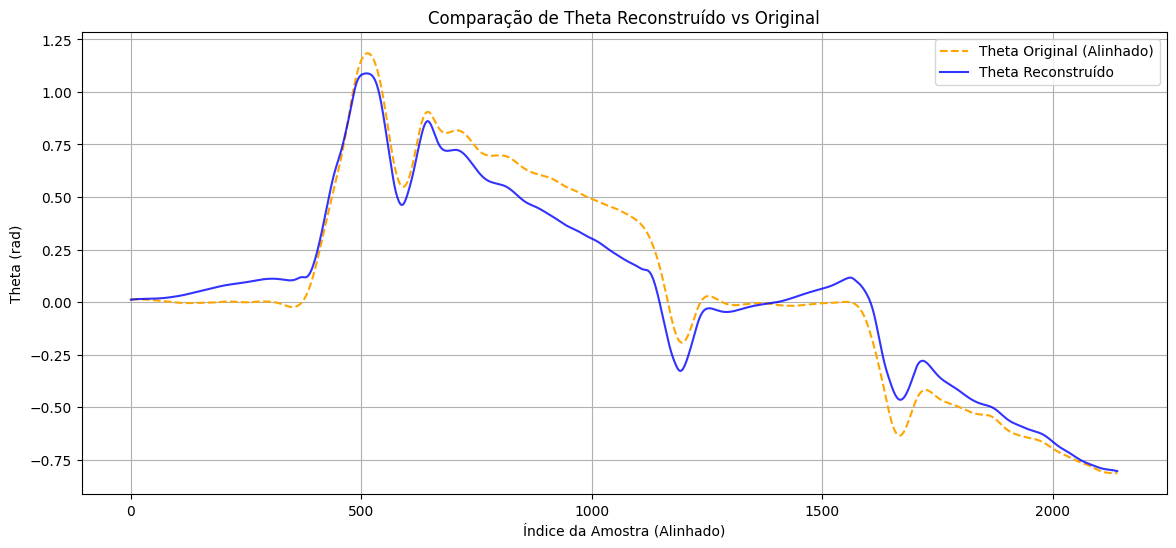

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
MSE entre Theta Original e Reconstruído: 0.3608


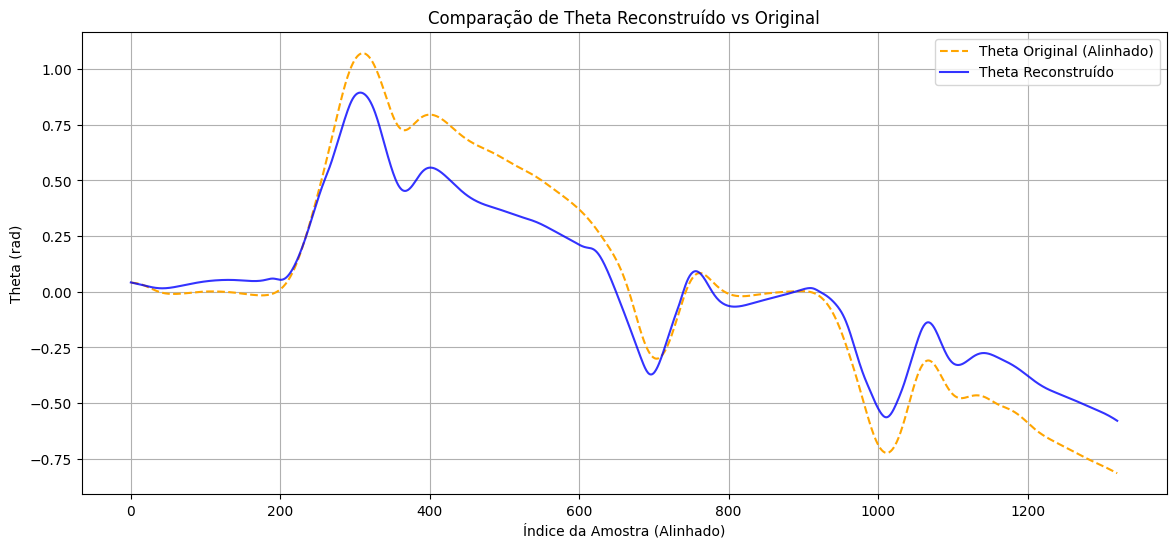

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MSE entre Theta Original e Reconstruído: 0.2182


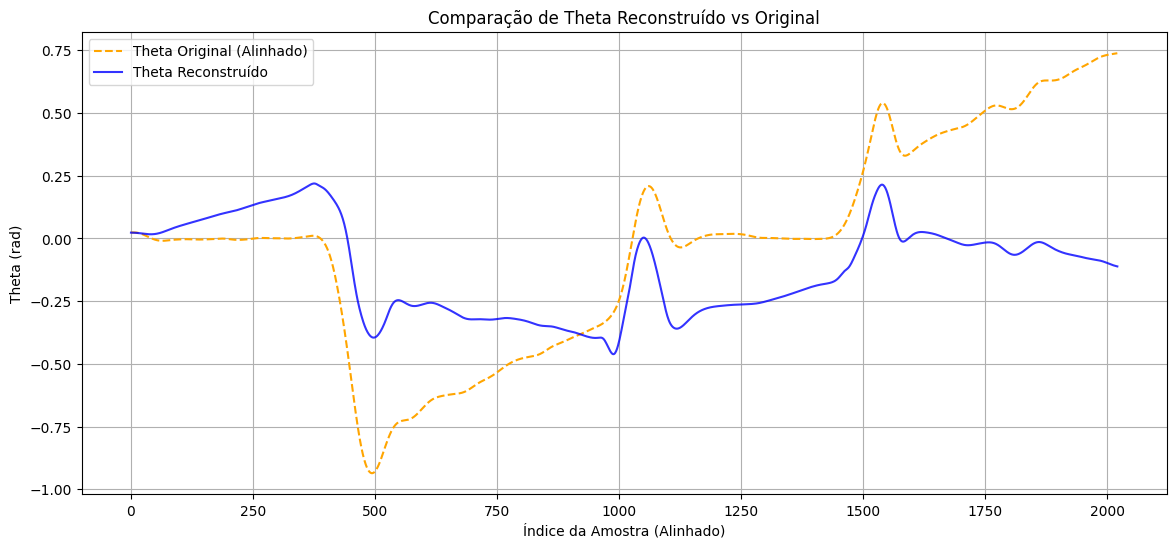

In [12]:

try:
    results_df = pd.read_csv('model_training_results.csv')
except FileNotFoundError:
    print("Erro: O arquivo 'model_training_results.csv' não foi encontrado. Certifique-se de que o treinamento foi executado.")
else:
    # 2. Encontre o melhor modelo
    # Como o DataFrame já está ordenado, o primeiro registro é o melhor
    best_model_row = results_df.iloc[0]
    best_model_path = best_model_row['model_file']

    print("\n--- Carregando o melhor modelo ---")
    print(f"Melhor modelo a ser carregado: {best_model_path}")
    print(f"Métricas de Teste do melhor modelo (R2): {best_model_row['R2_Test']:.4g}")
    print(f"Métricas de Teste do melhor modelo (MSE): {best_model_row['MSE_Test']:.4g}")
    
    # 3. Carregue o modelo
    try:
        # A função load_model carrega o modelo salvo
        best_model = keras.models.load_model(best_model_path)
        print("\nModelo carregado com sucesso!")
        
        # Opcional: verifique a estrutura do modelo
        # best_model.summary()
        
    except FileNotFoundError:
        print(f"Erro: O arquivo do modelo '{best_model_path}' não foi encontrado.")

# Avaliação do melhor modelo
if 'best_model' in locals():
    print("\n--- Avaliando o melhor modelo ---")
    Aval_Thetha(best_model, time_steps=int(best_model_row['time_steps']), y_scaler=y_scaler)    